<h1><b>Problem Statement</b></h1>
<p>This Prediction Model is built to teach the AI solution (MammaCare) , to predict levels of urgency ( low, mid or high risk) from the womens pregnancy symptoms .</p>
<br>
<b>Input:</b> Symptom description (eg. Bleeding, headache etc)<br>
<b>Output</b>: 'Emergency' , 'Urgent','Non-urgent' predictions <br>

<br>
The goal is to minimize false negatives and increase accuracy results

In [47]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h1><b> Data Collection</b></h1>

In [48]:
df = pd.read_csv(r"Maternal_Risk_Prediction/Maternal Health Risk Data Set.csv")
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


<h1><b> Data Cleaning and Preprocessing</b></h1>
This includes Data analysis (EDA).
<br>
We will explore the data and clean it

<br><br>
1) <b>We check for missing values </b>

In [49]:
#missing values for each column
missing_values = df.isnull().sum()
missing_values

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

No missing values found <br>
Now we <b>explore all numerical variables</b>

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


Lets check the <b>relationship between numerical features .</b>
<br>
Here we are checking multicollinearity

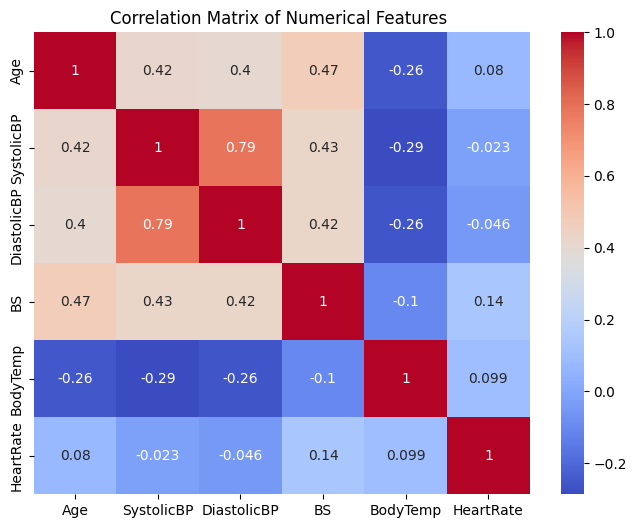

In [51]:
#isolate non target features
features = df.drop(columns=["RiskLevel"])

#correlation matrix
corr_matrix = features.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap= 'coolwarm')
plt.title("Correlation Matrix of Numerical Features ")
plt.show()

From the heatmap we see that <b>SystolicBP and DiastolicBP have a strong correlation (between 70%-90%)</b><br>
Will have to fix it when we fit the dataset into a model. L2 regularization 
<br><br>

Lets check for <b>Outliers</b>

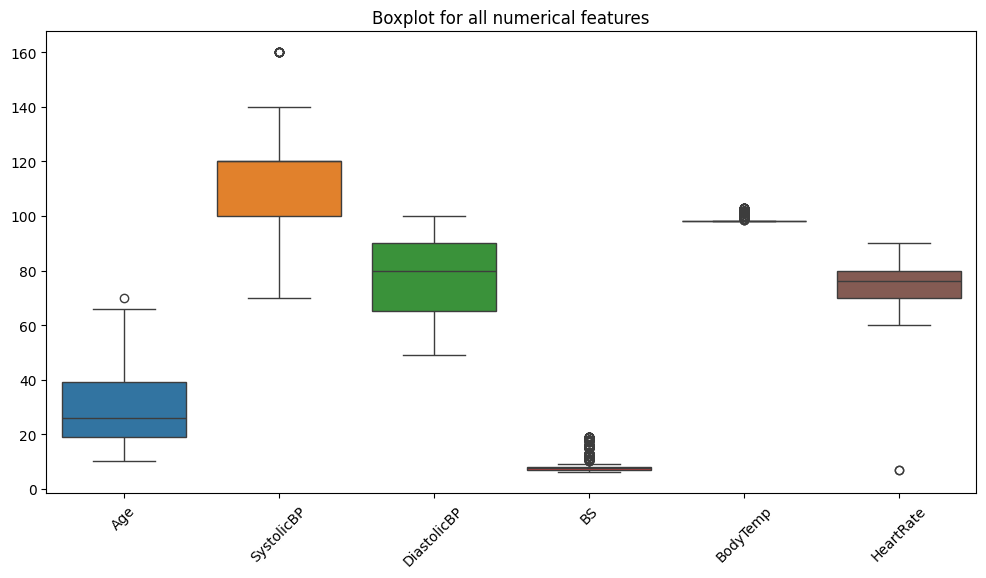

In [52]:
#boxplot to check for outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for all numerical features")
plt.show()

<b>All features except DiastolicBP have outliers .</b> <br>
Will fix that in the Feature Engineering section

<h1><b> Feature Engineering </b></h1>
 <br>
1) remove any outliers 

In [59]:
#IQR method to remove outliers
df_clean = df.copy()
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    df_clean = df_clean[(df_clean[col]>=lower_bound)&(df_clean[col]<=upper_bound)]

print(df_clean)

      Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
3      30         140           85  7.00      98.0         70  high risk
4      35         120           60  6.10      98.0         76   low risk
5      23         140           80  7.01      98.0         70  high risk
6      23         130           70  7.01      98.0         78   mid risk
8      32         120           90  6.90      98.0         70   mid risk
...   ...         ...          ...   ...       ...        ...        ...
964    35         140          100  8.00      98.0         66  high risk
981    25         140          100  7.20      98.0         80  high risk
985    32         140          100  8.00      98.0         70  high risk
997    35         140          100  9.00      98.0         66  high risk
1007   40         120           75  7.70      98.0         70  high risk

[620 rows x 7 columns]


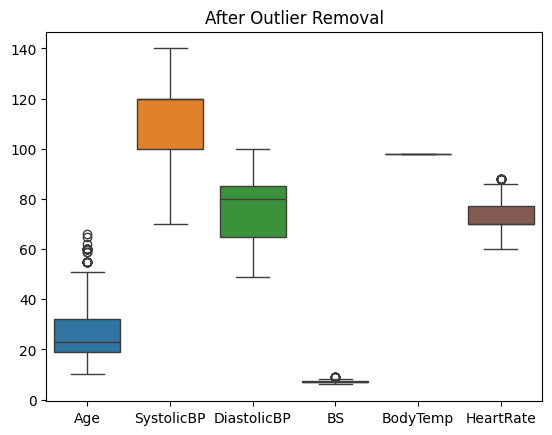

In [62]:
sns.boxplot(data=df_clean.drop(columns=['RiskLevel']))
plt.title("After Outlier Removal")
plt.show()

In [57]:
# Create a mask for outliers across all features
mask = pd.Series([True] * len(df))

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= (df[col]>=lower_bound) & (df[col] <= upper_bound)

df_clean = df[mask]
print(df_clean)

      Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
3      30         140           85  7.00      98.0         70  high risk
4      35         120           60  6.10      98.0         76   low risk
5      23         140           80  7.01      98.0         70  high risk
6      23         130           70  7.01      98.0         78   mid risk
8      32         120           90  6.90      98.0         70   mid risk
...   ...         ...          ...   ...       ...        ...        ...
964    35         140          100  8.00      98.0         66  high risk
981    25         140          100  7.20      98.0         80  high risk
985    32         140          100  8.00      98.0         70  high risk
997    35         140          100  9.00      98.0         66  high risk
1007   40         120           75  7.70      98.0         70  high risk

[620 rows x 7 columns]


<h1> Data Splitting</h1>

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["RiskLevel"])
y = df["RiskLevel"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [29]:
print(X_train)

     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate
479   15         120           80  7.9      98.0         70
47    23          90           60  7.5      98.0         76
529   23         120           75  8.0      98.0         70
647   29         130           70  8.0      98.0         78
19    10          70           50  6.9      98.0         70
..   ...         ...          ...  ...       ...        ...
767   21         120           80  6.9      98.0         76
72    19         120           80  7.0      98.0         70
908   16         120           75  7.9      98.0          7
235   28         120           80  9.0     102.0         76
37    55         100           65  6.1      98.0         66

[811 rows x 6 columns]


In [30]:
print(X_train)

     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate
479   15         120           80  7.9      98.0         70
47    23          90           60  7.5      98.0         76
529   23         120           75  8.0      98.0         70
647   29         130           70  8.0      98.0         78
19    10          70           50  6.9      98.0         70
..   ...         ...          ...  ...       ...        ...
767   21         120           80  6.9      98.0         76
72    19         120           80  7.0      98.0         70
908   16         120           75  7.9      98.0          7
235   28         120           80  9.0     102.0         76
37    55         100           65  6.1      98.0         66

[811 rows x 6 columns]


In [31]:
print(y_train)

479     low risk
47      low risk
529     mid risk
647     mid risk
19      low risk
         ...    
767     mid risk
72      mid risk
908     low risk
235    high risk
37      low risk
Name: RiskLevel, Length: 811, dtype: object


<h1> Feature Scaling</h1>

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-0.36173812  0.91339632  0.25502279  1.90589019 -0.4852155   1.44695615]
 [ 0.38077697  1.45702716  0.97553854  1.29833966 -0.4852155  -0.53208757]
 [-0.06473208 -1.26112705 -0.46549297 -0.22053665  0.97388449  0.70481475]
 ...
 [ 0.38077697 -1.53294248 -1.18600873  3.12099124 -0.4852155   1.44695615]
 [ 0.97478904  0.36976548  0.97553854  2.81721597 -0.4852155  -0.53208757]
 [ 0.15802244  0.36976548 -0.82575085 -0.82808717  1.70343448  0.21005383]]


<b><h1>Model Building + L2 Regularization </h1> to eliminate multicollinearity</b>

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression( penalty='l2', C=0.1, solver='lbfgs')
model.fit(X_scaled,y)

LogisticRegression(C=0.1)

In [42]:
y_pred = model.predict(X_scaled)
y_pred

array(['high risk', 'high risk', 'low risk', ..., 'high risk',
       'high risk', 'mid risk'], dtype=object)

<h1> Evaluation</h1>

In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y,y_pred))

              precision    recall  f1-score   support

   high risk       0.74      0.71      0.73       272
    low risk       0.64      0.82      0.72       406
    mid risk       0.48      0.34      0.40       336

    accuracy                           0.63      1014
   macro avg       0.62      0.62      0.61      1014
weighted avg       0.62      0.63      0.61      1014



F1-Score shows better results because it has a balance betweem precision and recall


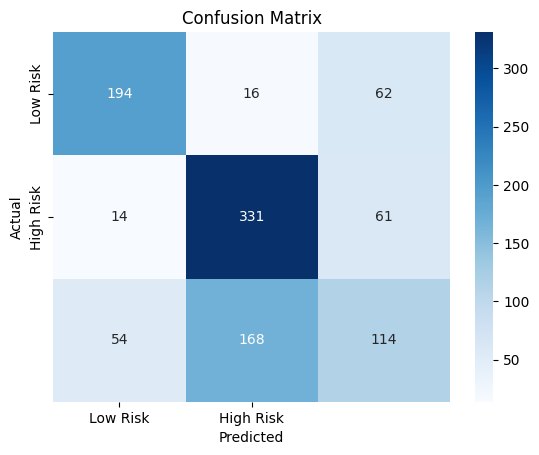

In [45]:
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk','High Risk'], yticklabels=['Low Risk','High Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<b>Results:</b><br>
Low Risk True positive Results: 194<br>
Low Risk which is actually high: 16<br>
High risk True Negative results: 331<br>
HIgh risk which is in fact Low risk: 14<br>
<br>

Model works well but can be improved more .